# Week 3: Imbalanced Classification and LightGBM Modeling

## Introduction

The objective of Week 3 is to develop a robust machine learning model for predicting machine failures using the enriched dataset prepared during Weeks 1 and 2. Since machine failures are relatively rare, the dataset is highly imbalanced, making it essential to apply techniques that improve the model's ability to detect minority-class failures.

In this phase, Synthetic Minority Over-sampling Technique (SMOTE) is applied to balance the training data before model training. A LightGBM classifier is then trained using Stratified Cross-Validation to ensure reliable performance across different data splits. Finally, the model is evaluated using accuracy, precision, recall, Macro F1 score, and SHAP explainability to understand the contribution of each feature to the prediction process.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df=pd.read_csv(r"C:\Users\tange\week2_processed_data.csv")

In [17]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Torque_RollingMean,Torque_RollingStd,Torque_RollingVar,...,Temp_Ratio,RPM_per_Torque,Ambient_Temperature,Humidity,Factory_Load,Shift,Heat_Stress,Load_Torque,Humidity_Wear,Temp_Load
0,1,298.2,308.7,1408,40.0,9,0,43.60,4.223150,17.835,...,1.035211,34.341463,31.986857,68,0.782904,0,9874.342636,31.316173,612,25.042648
1,2,298.1,308.6,1425,41.9,11,0,43.42,4.284507,18.357,...,1.035223,33.216783,29.446943,61,0.962677,2,9087.326547,40.336185,671,28.347908
2,1,298.1,308.6,1558,42.4,14,0,42.64,3.972782,15.783,...,1.035223,35.898618,32.590754,59,0.512720,0,10057.506731,21.739347,826,16.709946
3,1,298.1,308.6,1527,40.2,16,0,40.80,1.270827,1.615,...,1.035223,37.063107,36.092119,45,0.854098,2,11138.028055,34.334738,720,30.826206
4,2,298.3,308.7,1667,28.6,18,0,38.62,5.697543,32.462,...,1.034864,56.317568,29.063387,82,0.665164,1,8971.867413,19.023686,1476,19.331914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,2,298.8,308.4,1604,29.5,14,0,34.00,8.997222,80.950,...,1.032129,52.590164,30.765803,79,0.672882,1,9488.173603,19.850022,1106,20.701758
9992,0,298.9,308.4,1632,31.8,17,0,35.14,8.058102,64.933,...,1.031783,49.756098,32.648675,52,0.713745,2,10068.851375,22.697085,884,23.302823
9993,2,299.0,308.6,1645,33.4,22,0,33.98,7.738669,59.887,...,1.032107,47.819767,24.005458,62,0.863355,0,7408.084342,28.836052,1364,20.725228
9994,0,299.0,308.7,1408,48.5,25,0,34.22,8.256331,68.167,...,1.032441,28.444444,34.776858,43,0.605792,2,10735.616044,29.380908,1075,21.067539


In [18]:
df.rename(columns={
    'Air temperature [K]': 'Air_Temperature',
    'Process temperature [K]': 'Process_Temperature',
    'Rotational speed [rpm]': 'Rotational_Speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool_Wear',
    'Machine failure': 'Machine_Failure'
}, inplace=True)

In [22]:
X = df.drop('Machine_Failure', axis=1)

y = df['Machine_Failure']

In [23]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:

from imblearn.over_sampling import SMOTE

In [26]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [27]:
from lightgbm import LGBMClassifier

In [28]:
model = LGBMClassifier(
    random_state=42
)

model.fit(
    X_train_smote,
    y_train_smote
)

[LightGBM] [Info] Number of positive: 7725, number of negative: 7725
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7957
[LightGBM] [Info] Number of data points in the train set: 15450, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [33]:
print(classification_report(y_test, y_pred))

print("Macro F1:",f1_score(
    y_test,
    y_pred,
    average='macro'))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.88      0.84      0.86        68

    accuracy                           0.99      2000
   macro avg       0.94      0.92      0.93      2000
weighted avg       0.99      0.99      0.99      2000

Macro F1: 0.9261147438028741


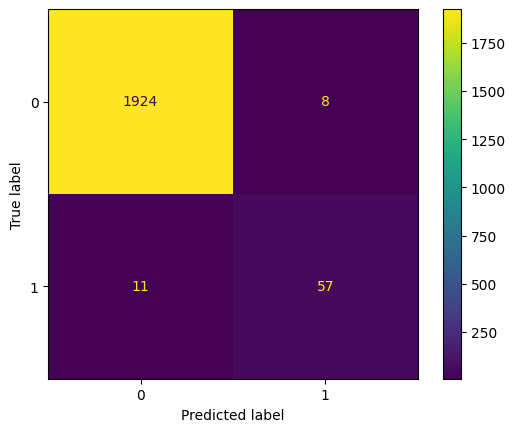

In [34]:
cm = confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print(scores)

print(scores.mean())


[LightGBM] [Info] Number of positive: 271, number of negative: 7725
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001927 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7437
[LightGBM] [Info] Number of data points in the train set: 7996, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033892 -> initscore=-3.350098
[LightGBM] [Info] Start training from score -3.350098
[LightGBM] [Info] Number of positive: 272, number of negative: 7725
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000568 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7437
[LightGBM] [Info] Number of data points in the train set: 7997, number of used features: 34
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034013 -> initscore=-3.346415
[LightGBM]

In [36]:
import shap

In [37]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

C:\Users\tange\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


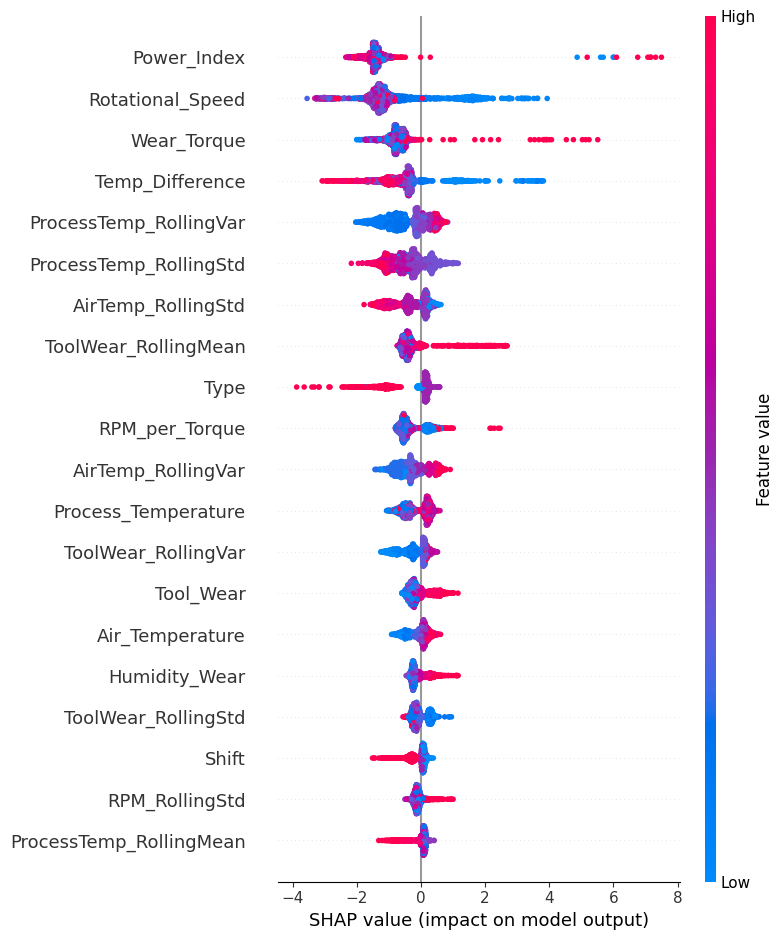

In [39]:
shap.summary_plot(shap_values, X_test)

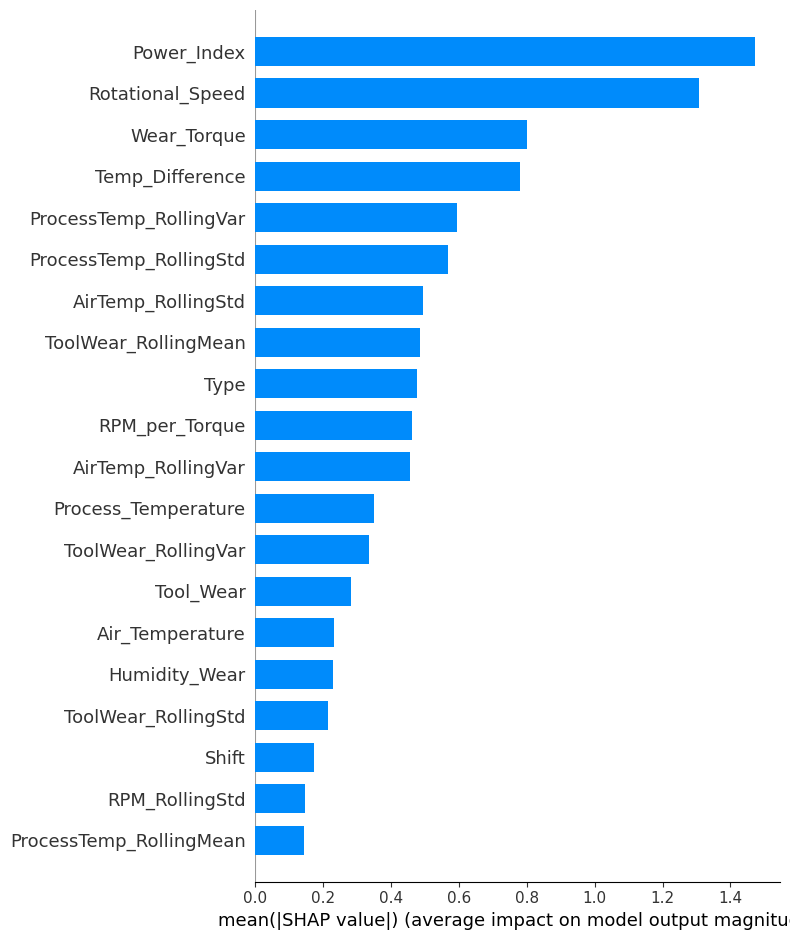

In [40]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [45]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [47]:
!pip install joblib
import joblib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
joblib.dump(
    model,
    "predictive_maintenance_model.pkl"
)

['predictive_maintenance_model.pkl']

# Summary

During Week 3, an imbalanced classification pipeline was developed to predict machine failures using the enriched dataset created in the previous stages. SMOTE was applied to balance the minority failure class before model training, reducing bias toward the majority class.

A LightGBM classifier was trained and evaluated using stratified cross-validation to ensure robust performance. Model performance was assessed using accuracy, precision, recall, and Macro F1 score. SHAP explainability techniques were used to interpret feature importance and understand how different sensor and contextual variables contributed to machine failure predictions. Finally, the trained model was saved for deployment and further evaluation in Week 4.# Week 3 Summary

During Week 3, an imbalanced classification pipeline was developed to predict machine failures using the enriched dataset created in the previous stages. SMOTE was applied to balance the minority failure class before model training, reducing bias toward the majority class.

A LightGBM classifier was trained and evaluated using stratified cross-validation to ensure robust performance. Model performance was assessed using accuracy, precision, recall, and Macro F1 score. SHAP explainability techniques were used to interpret feature importance and understand how different sensor and contextual variables contributed to machine failure predictions. Finally, the trained model was saved for deployment and further evaluation in Week 4.v